In [ ]:
from loaders.load import load_anomaly_archive
import numpy as np

In [6]:
ucr_train, ucr_validation = load_anomaly_archive(group="train", validation=True)

Number of datasets: 250
DataEntity meta-data: {'name': '183_UCR_Anomaly_qtdbSel100MLII', 'train_end': 4000, 'anomaly_start_in_test': 9400, 'anomaly_end_in_test': 9800}
------------------------------------------
Entity:  183_UCR_Anomaly_qtdbSel100MLII
num_features:  1
num_exogenous:  0
num_timesteps:  3600
Anomaly %:  0.0
Mask %:  1.0
------------------------------------------
------------------------------------------
Entity:  183_UCR_Anomaly_qtdbSel100MLII
num_features:  1
num_exogenous:  0
num_timesteps:  400
Anomaly %:  0.0
Mask %:  1.0
------------------------------------------
DataEntity meta-data: {'name': '194_UCR_Anomaly_sddb49', 'train_end': 20000, 'anomaly_start_in_test': 47950, 'anomaly_end_in_test': 48200}
------------------------------------------
Entity:  194_UCR_Anomaly_sddb49
num_features:  1
num_exogenous:  0
num_timesteps:  18000
Anomaly %:  0.0
Mask %:  1.0
------------------------------------------
------------------------------------------
Entity:  194_UCR_Anomaly_

In [7]:
sample_entity = ucr_train.entities[0]
sample_entity

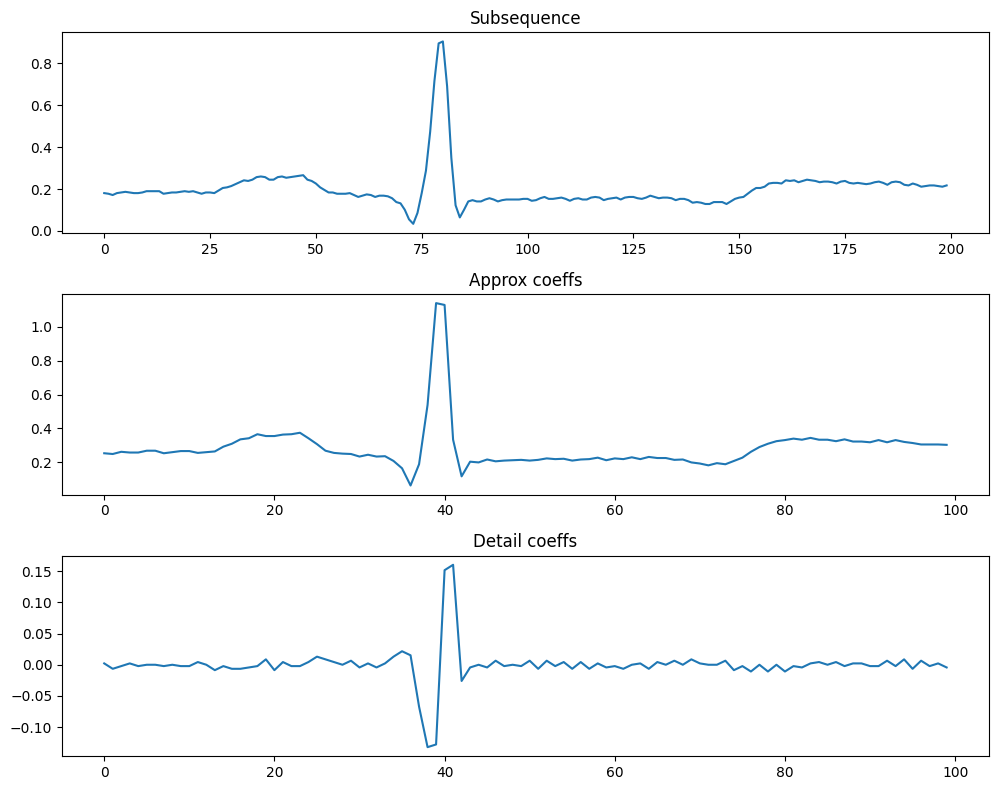

In [ ]:
sample_len = sample_entity.Y.shape[1]
sublen = 200
start = np.random.randint(0, sample_len - sublen)
subsequence = sample_entity.Y[0][start : start + sublen]

# https://pywavelets.readthedocs.io/en/latest/ref/dwt-discrete-wavelet-transform.html
import pywt
(cA, cD) = pywt.dwt(subsequence, "db1")
# Using Daubechies wavelets

import matplotlib.pyplot as plt
fig, ax = plt.subplots(3, 1, figsize=(10,8))

ax[0].plot(subsequence)
ax[0].set_title("Subsequence")

ax[1].plot(cA)
ax[1].set_title("Approx coeffs")

ax[2].plot(cD)
ax[2].set_title("Detail coeffs")

plt.tight_layout()
plt.show()

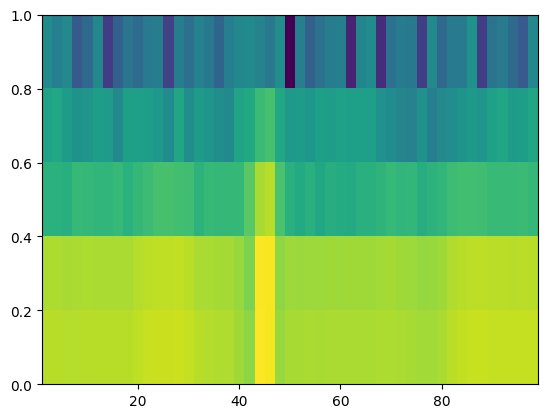

In [26]:
sample_len = sample_entity.Y.shape[1]
sublen = 200
start = np.random.randint(0, sample_len - sublen)
subsequence = sample_entity.Y[0][start : start + sublen]

plt.specgram(subsequence, NFFT=8, noverlap=4);

In [34]:
fft_result = np.fft.fft(subsequence)
fft_result

array([ 3.97308869e+01+0.00000000e+00j,  4.88147485e-01-2.46241048e+00j,
        1.45096656e+00+3.10926773e+00j, -1.46508897e+00+5.83945940e-01j,
        9.87667397e-01+3.05111422e+00j, -3.82899149e-01-4.05315004e+00j,
       -1.33244195e+00+2.57940687e+00j,  2.63539226e+00-1.49539921e+00j,
       -2.41285450e+00+1.85299223e+00j,  2.83324875e+00-4.55949842e-01j,
       -3.07086411e+00-5.84997428e-01j,  2.80078057e+00+1.52053957e+00j,
       -2.05593455e+00-2.39242477e+00j,  8.81041479e-01+3.22927090e+00j,
        3.00131997e-01-2.94862863e+00j, -1.25974020e+00+2.56450887e+00j,
        1.74310114e+00-2.01245346e+00j, -2.41410200e+00+1.42400739e+00j,
        2.55515275e+00-2.42100399e-01j, -2.40988028e+00-4.40689384e-01j,
        1.79929412e+00+1.33150362e+00j, -1.24019447e+00-1.62264911e+00j,
        6.32172315e-01+1.75713786e+00j, -1.85615393e-01-1.67266968e+00j,
       -3.94008667e-01+1.64294055e+00j,  7.25036185e-01-1.14005355e+00j,
       -8.89584847e-01+8.79476142e-01j,  1.17127262